<a href="https://colab.research.google.com/github/harshithachanta/Decisiontree/blob/main/Decisiontree(heart).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# dataset:-https://drive.google.com/file/d/1tzpH9Z6I_Mt7swHJzFgoZZl2AevfeTH-/view?usp=sharing

In [2]:
df=pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


age: the age of the patient in years.

sex: the sex of the patient (1 = male, 0 = female).

cp: the type of chest pain the patient experienced (1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic).

trestbps: the resting blood pressure of the patient in mm Hg.

chol: the serum cholesterol level of the patient in mg/dl.

fbs: the fasting blood sugar level of the patient, measured in mg/dl (1 = high, 0 = low).

restecg: the resting electrocardiographic results of the patient (0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy).

(Resting electrocardiographic (ECG or EKG) is a non-invasive diagnostic test that records the electrical activity of the heart while the patient is at rest. The test is performed using an electrocardiogram machine, which records the electrical signals produced by the heart through electrodes placed on the chest, arms, and legs.)

thalach: the maximum heart rate achieved by the patient during exercise. exang: whether the patient experienced exercise-induced angina (1 = yes, 0 = no).

oldpeak: the ST depression induced by exercise relative to rest. slope: the slope of the ST segment during peak exercise (1 = upsloping, 2 = flat, 3 = downsloping).

(ST depression induced by exercise relative to rest Oldpeak, also known as ST depression, is a common parameter measured during an exercise stress test to evaluate the presence and severity of coronary artery disease. It represents the amount of ST segment depression that occurs on an electrocardiogram (ECG) during exercise compared to rest.)

ca: the number of major vessels colored by fluoroscopy (0-3).

(he number of major vessels (0-3) colored by fluoroscopy is a parameter that is used to assess the severity of coronary artery disease (CAD) in patients who undergo coronary angiography)

thal: the type of thallium scan performed on the patient (1 = fixed defect, 2 = reversible defect, 3 = normal).

target: the presence of heart disease in the patient (0 = no disease, 1 = disease present).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
#EDA
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


In [9]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

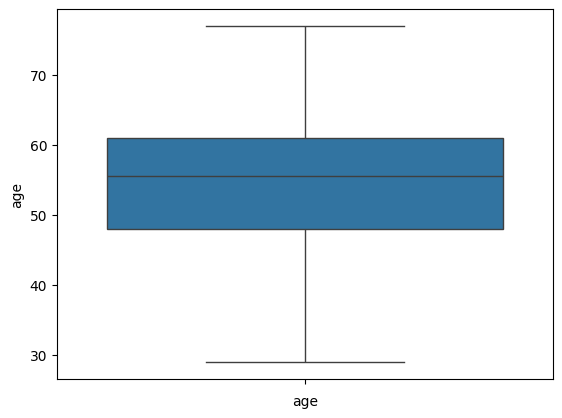

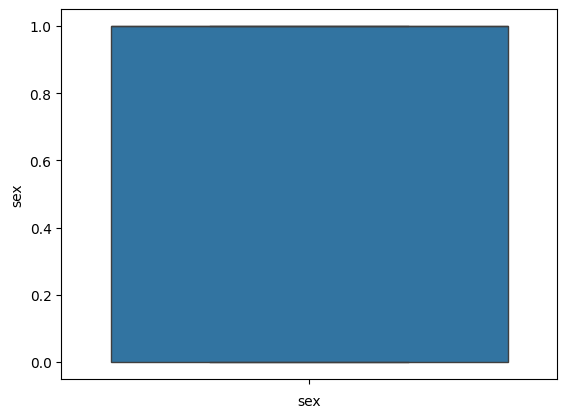

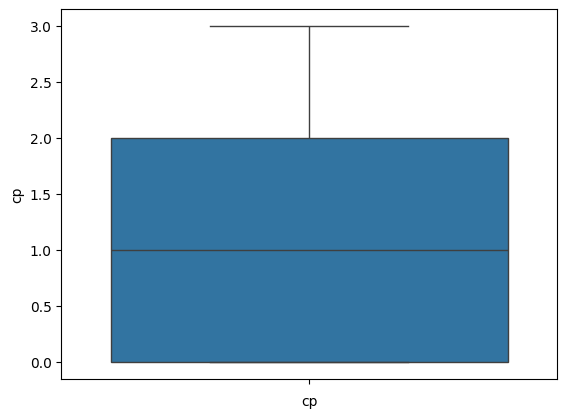

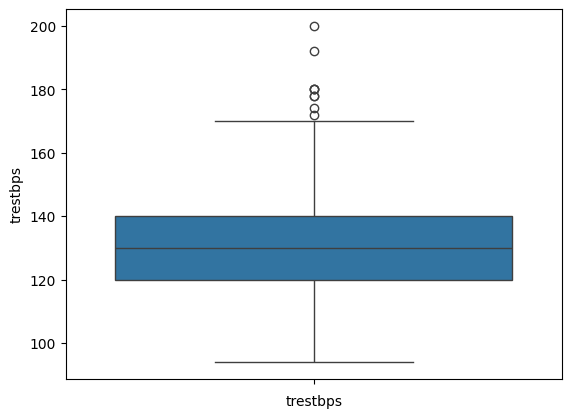

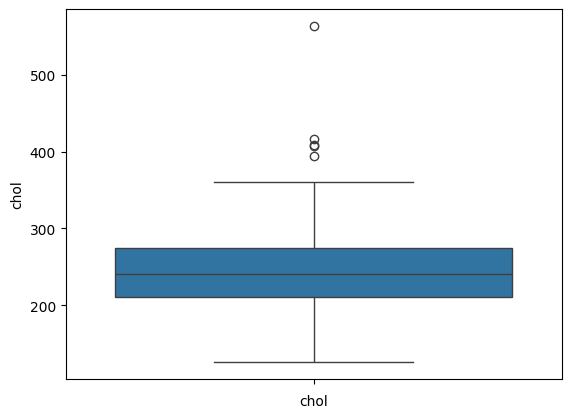

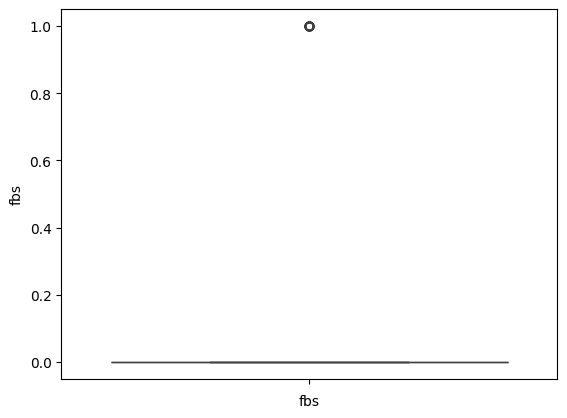

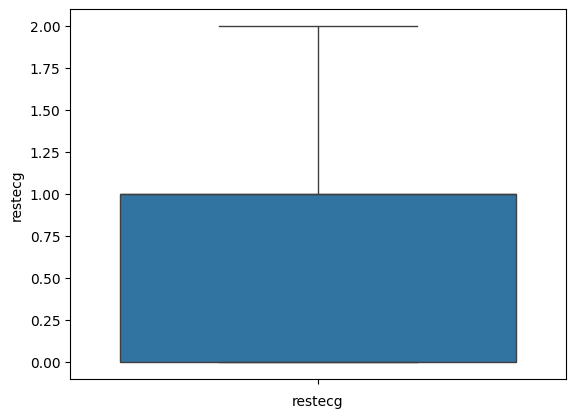

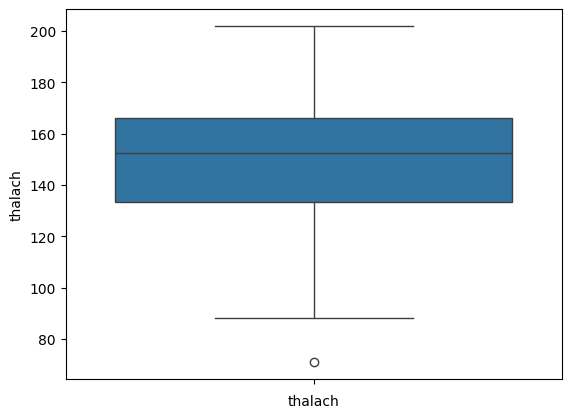

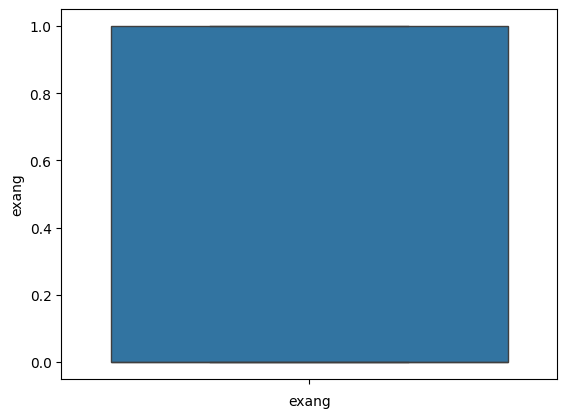

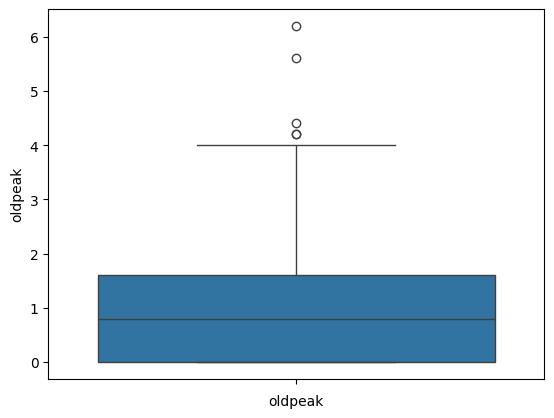

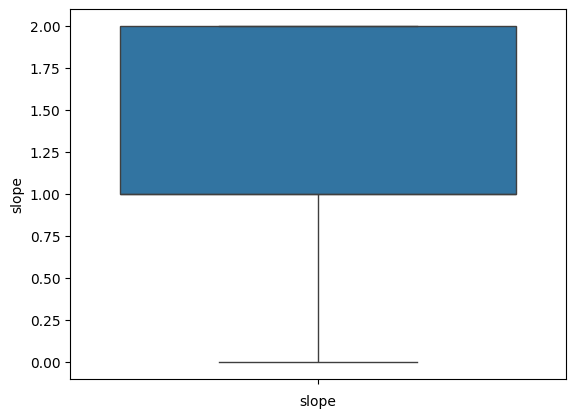

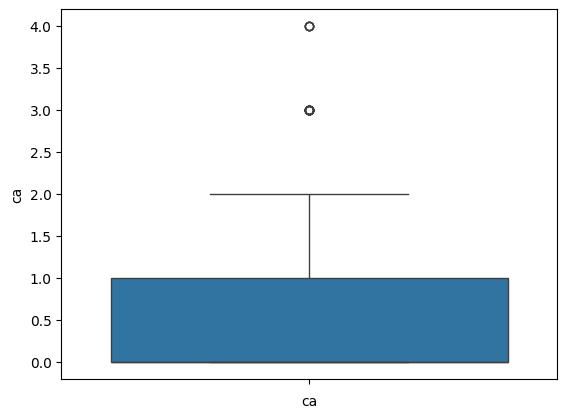

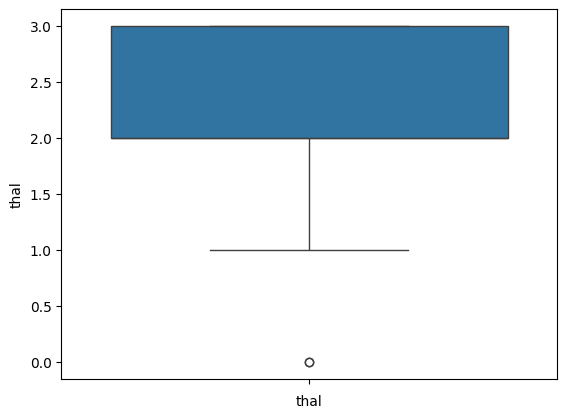

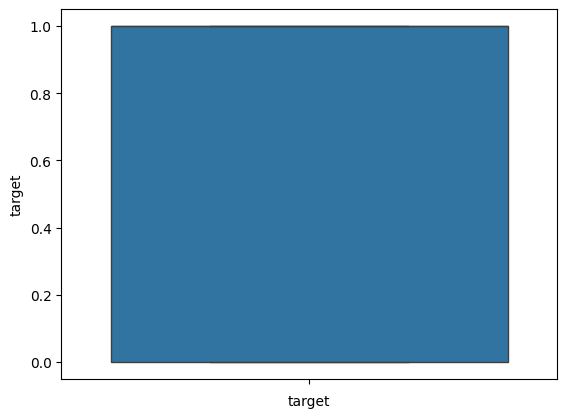

In [10]:
for col in df.columns:
  if(df[col].dtype != 'object'):
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [11]:
# outlier_col=['trestbps','chol','thalach','oldpeak','ca','thal']
#the outliers will get segrigated at the leaf nodes.
#y = w1x1+w2x2+w3x3+....+wnxn +b
# for col in outlier_col:
#   Q1= df[col].quantile(0.25)
#   Q3= df[col].quantile(0.75)

#   IQR=Q3-Q1

#   LB=Q1-1.5(IQR)
#   UB=Q3+1.5(IQR)

#   df=df[(df[col]>=LB) & (df[col]<=UB)]



In [12]:
#model building
# 1.split data in terms of x and y
# 2.split x and y in terms of training and testing
# 3.initialize model
# 4.train the model
# 5.predictions (testing)


In [13]:
df.drop('target',axis=1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [14]:
x=df.drop('target',axis=1)
y=df['target']

In [15]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [16]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [19]:
x_train.shape

(226, 13)

In [20]:
x_test.shape

(76, 13)

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
model=DecisionTreeClassifier()

In [23]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [24]:
y_pred=model.predict(x_test)

In [25]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1])

In [26]:
y_test

,target
180,0
229,0
111,1
247,0
60,1
...,...
22,1
259,0
56,1
243,0


In [27]:
from sklearn.metrics import *

In [28]:
accuracy_score(y_pred,y_test)*100

78.94736842105263

In [29]:
confusion_matrix(y_pred,y_test)

array([[31, 12],
       [ 4, 29]])

In [ ]:
# [actual,predict] no.
# [0,0] 31  --> 31 coorectly predicted 0's
# [0,1] 12  --> wrongly predicted 0's
# [1,0] 4   --> wrongly predicted 1's
# [1,1] 29  --> correctly predicted 1's

In [30]:
max_depths=[2,3,4,5,6,7,8,10]
# model=DecisionTreeClassifier(max_depth=)
for depth in max_depths:
  temp_model=DecisionTreeClassifier(max_depth=depth)
  temp_model.fit(x_train,y_train)
  y_pred_temp=temp_model.predict(x_test)
  acc=accuracy_score(y_pred_temp,y_test)
  print(f"for the max depth value {depth} the accuracy id: {acc*100}")


for the max depth value 2 the accuracy id: 73.68421052631578
for the max depth value 3 the accuracy id: 78.94736842105263
for the max depth value 4 the accuracy id: 81.57894736842105
for the max depth value 5 the accuracy id: 76.31578947368422
for the max depth value 6 the accuracy id: 76.31578947368422
for the max depth value 7 the accuracy id: 78.94736842105263
for the max depth value 8 the accuracy id: 77.63157894736842
for the max depth value 10 the accuracy id: 78.94736842105263


In [31]:
final_model=DecisionTreeClassifier(max_depth=4)

In [32]:
final_model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4)

In [33]:
y_pred_final=final_model.predict(x_test)

In [34]:
#gridseach cv , Rndom search cv

from sklearn.tree import plot_tree

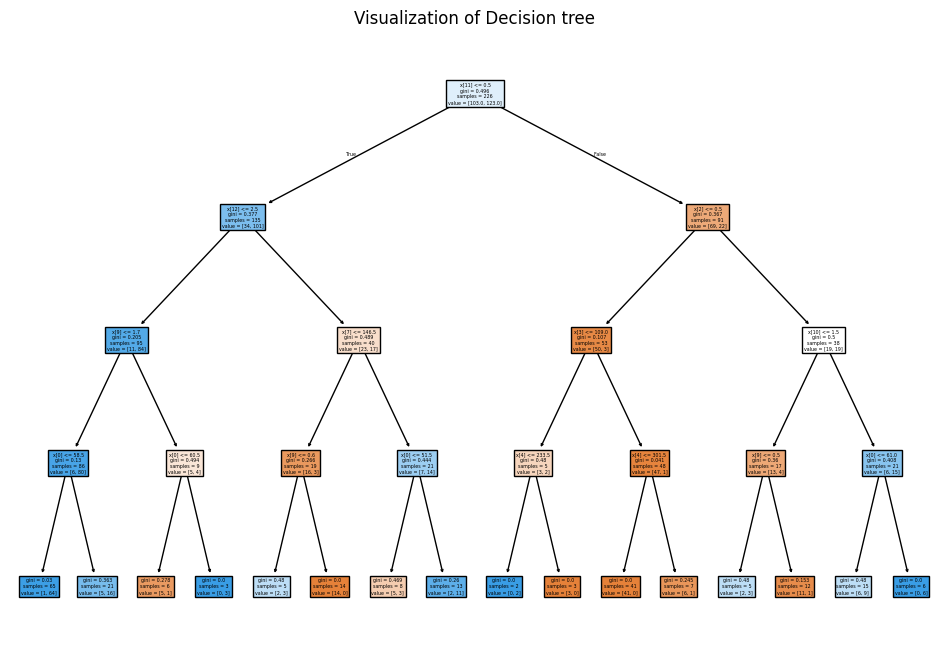

In [35]:
plt.figure(figsize=(12,8))
plot_tree(final_model,filled=True)
plt.title('Visualization of Decision tree')
plt.savefig('decsiotree.pdf')
plt.show()